In [2]:
import pandas as pd
import numpy as np

In [3]:
df=pd.read_csv("student-por.csv", sep=";")

In [4]:
df

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
644,MS,F,19,R,GT3,T,2,3,services,other,...,5,4,2,1,2,5,4,10,11,10
645,MS,F,18,U,LE3,T,3,1,teacher,services,...,4,3,4,1,1,1,4,15,15,16
646,MS,F,18,U,GT3,T,1,1,other,other,...,1,1,1,1,1,5,6,11,12,9
647,MS,M,17,U,LE3,T,3,1,services,services,...,2,4,5,3,4,2,6,10,10,10


In [5]:
df["pass"]=np.where(df["G3"]>=10,1,0)
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,pass
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,3,4,1,1,3,4,0,11,11,1
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,3,3,1,1,3,2,9,11,11,1
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,3,2,2,3,3,6,12,13,12,1
3,GP,F,15,U,GT3,T,4,2,health,services,...,2,2,1,1,5,0,14,14,14,1
4,GP,F,16,U,GT3,T,3,3,other,other,...,3,2,1,2,5,0,11,13,13,1


In [6]:
# 3. Drop original grade columns G1, G2, G3 to avoid leakage (optional)
df_model = df.drop(['G1','G2','G3'], axis=1)
df_model

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,pass
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,no,no,4,3,4,1,1,3,4,1
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,yes,no,5,3,3,1,1,3,2,1
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,yes,no,4,3,2,2,3,3,6,1
3,GP,F,15,U,GT3,T,4,2,health,services,...,yes,yes,3,2,2,1,1,5,0,1
4,GP,F,16,U,GT3,T,3,3,other,other,...,no,no,4,3,2,1,2,5,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
644,MS,F,19,R,GT3,T,2,3,services,other,...,yes,no,5,4,2,1,2,5,4,1
645,MS,F,18,U,LE3,T,3,1,teacher,services,...,yes,no,4,3,4,1,1,1,4,1
646,MS,F,18,U,GT3,T,1,1,other,other,...,no,no,1,1,1,1,1,5,6,0
647,MS,M,17,U,LE3,T,3,1,services,services,...,yes,no,2,4,5,3,4,2,6,1


In [7]:
# 4. Convert categorical variables to dummy / one-hot encoding
df_model = pd.get_dummies(df_model, drop_first=True)
df_model

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,...,guardian_mother,guardian_other,schoolsup_yes,famsup_yes,paid_yes,activities_yes,nursery_yes,higher_yes,internet_yes,romantic_yes
0,18,4,4,2,2,0,4,3,4,1,...,True,False,True,False,False,False,True,True,False,False
1,17,1,1,1,2,0,5,3,3,1,...,False,False,False,True,False,False,False,True,True,False
2,15,1,1,1,2,0,4,3,2,2,...,True,False,True,False,False,False,True,True,True,False
3,15,4,2,1,3,0,3,2,2,1,...,True,False,False,True,False,True,True,True,True,True
4,16,3,3,1,2,0,4,3,2,1,...,False,False,False,True,False,False,True,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
644,19,2,3,1,3,1,5,4,2,1,...,True,False,False,False,False,True,False,True,True,False
645,18,3,1,1,2,0,4,3,4,1,...,True,False,False,True,False,False,True,True,True,False
646,18,1,1,2,2,0,1,1,1,1,...,True,False,False,False,False,True,True,True,False,False
647,17,3,1,2,1,0,2,4,5,3,...,True,False,False,False,False,False,False,True,True,False


In [8]:
X=df_model.drop("pass", axis=1)
Y=df_model["pass"]

In [9]:
# 6. Train/test split (e.g. 70/30 split)
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train,Y_test=train_test_split(X,Y, test_size=0.3, random_state=42, stratify=Y)

In [10]:
# 7. Instantiate Decision Tree
from sklearn.tree import DecisionTreeClassifier
clf=DecisionTreeClassifier(max_depth=5, random_state=42)
clf.fit(X_train,Y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [11]:
Y_pred=clf.predict(X_test)

In [12]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy Score: ",accuracy_score(Y_test,Y_pred))
print("Classification Report: ", classification_report(Y_test,Y_pred))
print("Confusion Matrix : ", confusion_matrix(Y_test,Y_pred))

Accuracy Score:  0.7846153846153846
Classification Report:                precision    recall  f1-score   support

           0       0.34      0.43      0.38        30
           1       0.89      0.85      0.87       165

    accuracy                           0.78       195
   macro avg       0.62      0.64      0.63       195
weighted avg       0.81      0.78      0.79       195

Confusion Matrix :  [[ 13  17]
 [ 25 140]]


In [13]:
from sklearn.model_selection import GridSearchCV
# hyper parameter tunning
parameter={
    'max_depth':[3,5,7,10,None],
    'min_samples_split':[2,5,10],
    'min_samples_leaf':[1,2,4],
    'criterion':['gini', 'entropy']
}

dt=DecisionTreeClassifier(random_state=42)
grid=GridSearchCV(dt,param_grid=parameter, cv=5, scoring='accuracy',n_jobs=-1)

In [14]:
grid.fit(X_train,Y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [3, 5, 7, 10, None],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10]},
             scoring='accuracy')

In [15]:
print("best_parameter ",grid.best_params_)

best_parameter  {'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 10}


In [16]:
best_model=grid.best_estimator_

In [17]:
# Predict and evaluate
y_pred = best_model.predict(X_test)
print("Accuracy:", accuracy_score(Y_test, Y_pred))
print("Classification Report:\n", classification_report(Y_test, Y_pred))
print("Confusion Matrix:\n", confusion_matrix(Y_test, Y_pred))


Accuracy: 0.7846153846153846
Classification Report:
               precision    recall  f1-score   support

           0       0.34      0.43      0.38        30
           1       0.89      0.85      0.87       165

    accuracy                           0.78       195
   macro avg       0.62      0.64      0.63       195
weighted avg       0.81      0.78      0.79       195

Confusion Matrix:
 [[ 13  17]
 [ 25 140]]


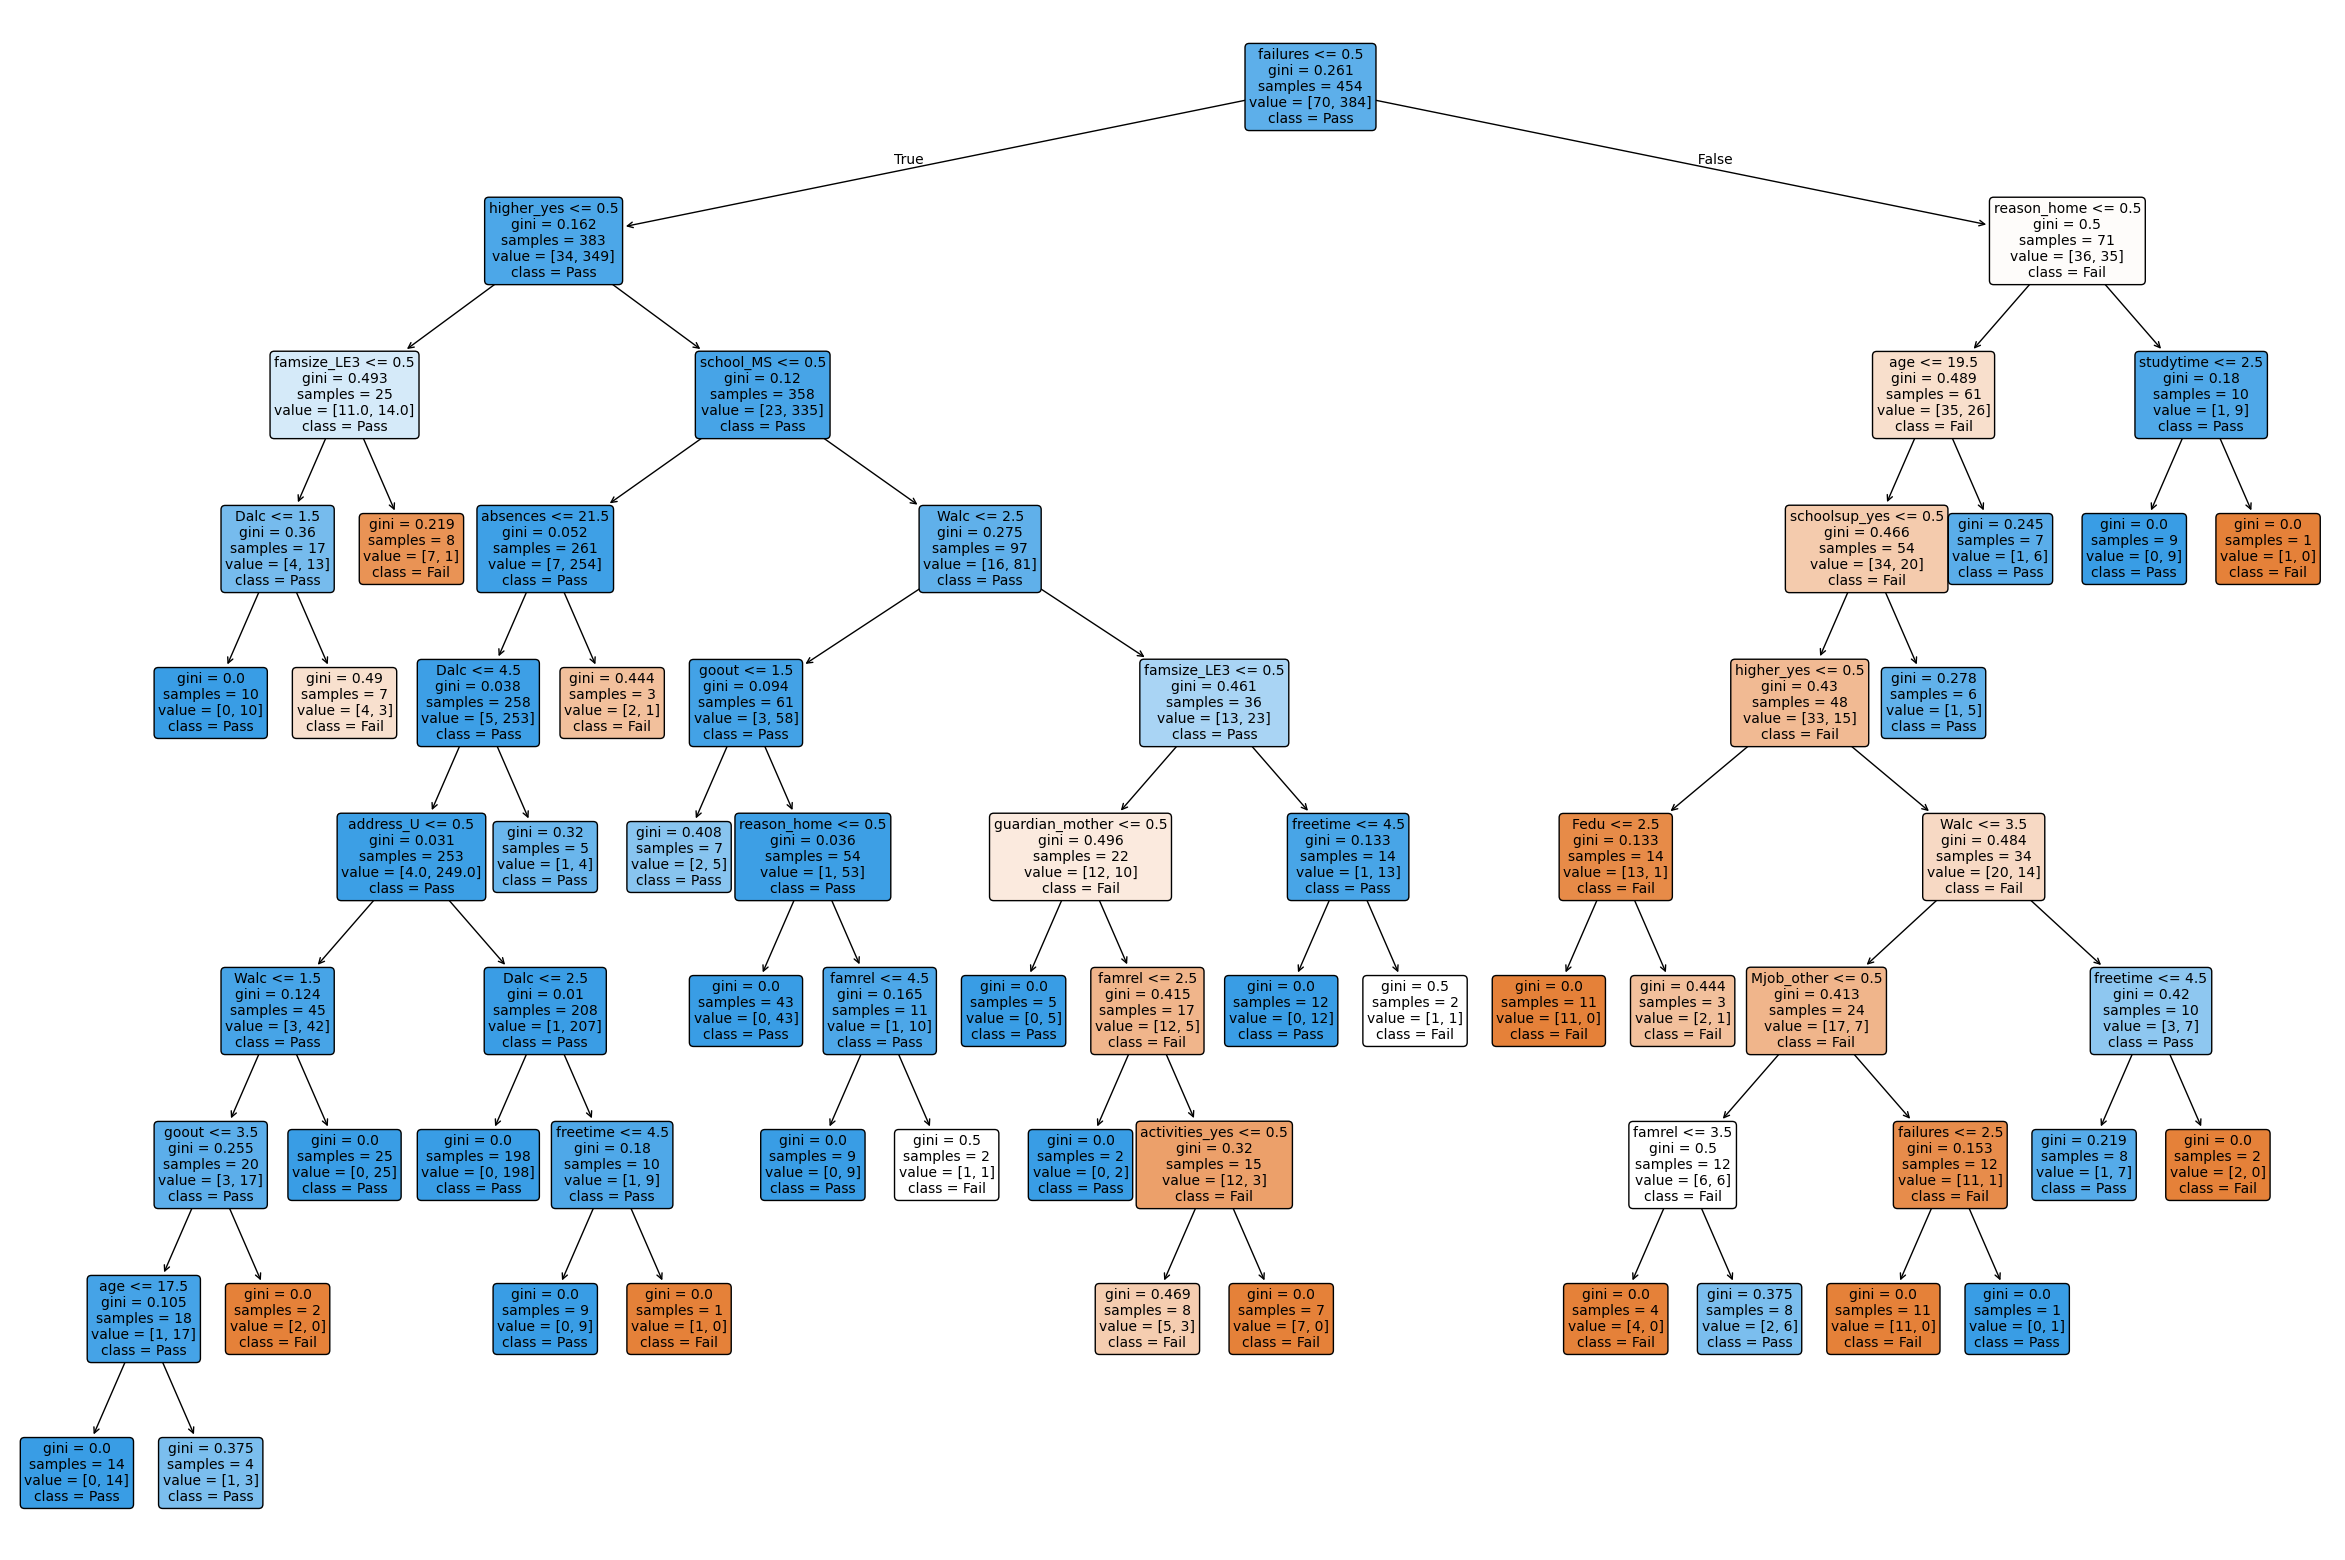

In [32]:
# Visualize the tree
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
plt.figure(figsize=(30, 20))
plot_tree( best_model, feature_names=X.columns, class_names=["Fail", "Pass"], filled=True,rounded=True, fontsize=10)
plt.show()